# Water heat capacity plotted from the triple point to the critical point

We will use thermodynamic data from the NIST chemistry webbook.

The thermodynamic properties of water are calcualted using the equation of state:

Wagner, W.; Pruss, A., The IAPWS Formulation 1995 for the Thermodynamic Properties of Ordinary Water Substance for General and Scientific Use, J. Phys. Chem. Ref. Data, 2002, 31, 2, 387-535, https://doi.org/10.1063/1.1461829 .

September 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# Typography, matching the recomputed figures in ch6 and ch7 (Figs. 6.6-1, 7.3-1 to
# 7.3-4, 7.5-2, 7.5-3): use a real LaTeX installation when there is one, so the figure is
# set in Computer Modern like the book, and fall back to matplotlib's own mathtext
# otherwise — the notebook still runs in Colab, which has no TeX. The fallback keeps a
# serif face and CM math.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

print(f"LaTeX typesetting: {'on (Computer Modern)' if mpl.rcParams['text.usetex'] else 'off (mathtext fallback)'}")

LaTeX typesetting: on (Computer Modern)


I saved the data from the NIST Webbook to an excel spreadsheet. I can use Pandas to read in the spreadsheet. 

With a Pandas dataframe, I can then check the data and print the column labels. Data can be selected with these names.

In [2]:
# Read excel spreadsheet of the data into a dataframe using pandas

df = pd.read_excel('water_lv_NIST.xlsx')

data = pd.DataFrame(df)
print(data)

     Temperature (K)  Pressure (MPa)  Density (l, mol/l)  Volume (l, l/mol)  \
0             273.16        0.000612              55.497           0.018019   
1             274.16        0.000658              55.500           0.018018   
2             275.16        0.000706              55.503           0.018017   
3             276.16        0.000759              55.504           0.018017   
4             277.16        0.000814              55.504           0.018017   
..               ...             ...                 ...                ...   
369           642.16       20.796000              25.650           0.038987   
370           643.16       21.046000              25.052           0.039918   
371           644.16       21.300000              24.340           0.041084   
372           645.16       21.557000              23.428           0.042683   
373           646.16       21.817000              22.114           0.045221   

     Internal Energy (l, kJ/mol)  Enthalpy (l, kJ/m

In [3]:
print(data.columns)

Index(['Temperature (K)', 'Pressure (MPa)', 'Density (l, mol/l)',
       'Volume (l, l/mol)', 'Internal Energy (l, kJ/mol)',
       'Enthalpy (l, kJ/mol)', 'Entropy (l, J/mol*K)', 'Cv (l, J/mol*K)',
       'Cp (l, J/mol*K)', 'Sound Spd. (l, m/s)', 'Joule-Thomson (l, K/MPa)',
       'Viscosity (l, uPa*s)', 'Therm. Cond. (l, W/m*K)',
       'Surf. Tension (l, N/m)', 'Density (v, mol/l)', 'Volume (v, l/mol)',
       'Internal Energy (v, kJ/mol)', 'Enthalpy (v, kJ/mol)',
       'Entropy (v, J/mol*K)', 'Cv (v, J/mol*K)', 'Cp (v, J/mol*K)',
       'Sound Spd. (v, m/s)', 'Joule-Thomson (v, K/MPa)',
       'Viscosity (v, uPa*s)', 'Therm. Cond. (v, W/m*K)'],
      dtype='str')


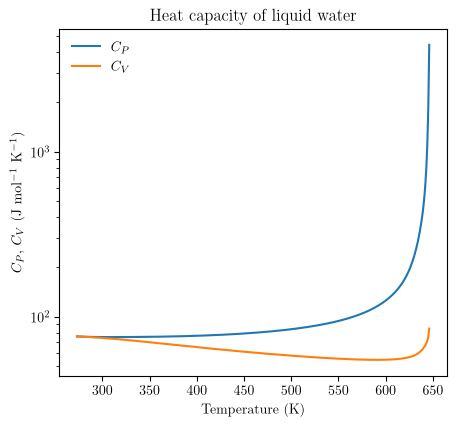

In [4]:
# plot the data from a dataframe

fig, ax1 = plt.subplots(1, 1, figsize=(5, 4.5))
ax1.set_yscale("log")

# Symbols set in math mode so they come out as Computer Modern italic under LaTeX.
# ("J/mol*K" would render its asterisk as a raised glyph once usetex is on.)
plt.xlabel(r'Temperature (K)')
plt.ylabel(r'$C_P$, $C_V$  (J mol$^{-1}$ K$^{-1}$)')
plt.title(r'Heat capacity of liquid water')

ax1.plot(data['Temperature (K)'], data['Cp (l, J/mol*K)'], '-', label=r'$C_P$')
ax1.plot(data['Temperature (K)'], data['Cv (l, J/mol*K)'], '-', label=r'$C_V$')

plt.legend(frameon=False)